In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from dfmodel import DigitalFamilyBinary
from dpks import QuantMatrix

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "../1_proteomics_data/protein_test_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']


In [4]:
proteomics_data_test = pd.read_csv(
    "../1_proteomics_data/protein_hero_filtered.tsv"
    , sep="\t"
)
clinical_data_test = pd.read_csv(
    "../0_clinical_data/design_matrix_hero.tsv",
    sep='\t'
)
clinical_data_test['sample'] = clinical_data_test['injection']
clinical_data_test = clinical_data_test[clinical_data_test['injection'].isin(proteomics_data_test.columns)].copy().reset_index()


In [5]:
clinical_data_train['survival_30_day'] = np.where(clinical_data_train['survival_days'] <= 30, 1, 0)
clinical_data_test['survival_30_day'] = np.where(clinical_data_test['survival_days'] <= 30, 1, 0)


clinical_data_train['future_od'] = np.where(
    (clinical_data_train['sofa_score_increase_day2'] > 1) & (clinical_data_train['sofa_score_increase_day3'] > 1), 1, 0
)
clinical_data_test['future_od'] = np.where(
    (clinical_data_test['sofa_score_increase_day2'] > 1) & (clinical_data_test['sofa_score_increase_day3'] > 1), 1, 0
)

In [6]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)
quant_matrix_test = preprocess_data(proteomics_data_test, design_matrix=clinical_data_test)

In [7]:
selected_features = pd.read_csv(
    "../4_high_risk_sepsis_df/sepsis_feature_importances.tsv",
    sep="\t",
)['feature'].to_list()

In [8]:
training_data, _ = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))
testing_data, _ = quant_matrix_test.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))

In [9]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
training_data[selected_features] = protein_scaler.fit_transform(training_data[selected_features])

testing_data[selected_features] = protein_scaler.transform(testing_data[selected_features])

In [10]:
training_data = clinical_data_train.set_index("injection").join(
    training_data
).reset_index()

testing_data = clinical_data_test.set_index("injection").join(
    testing_data
).reset_index()

In [11]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [12]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=True)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_od", bootstrap=True)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
training_data['ICU'] = df_estimator.predict(training_data, features=selected_features, target_column="critical_care", bootstrap=True)

In [13]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [14]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "30 Day Mortality"
]

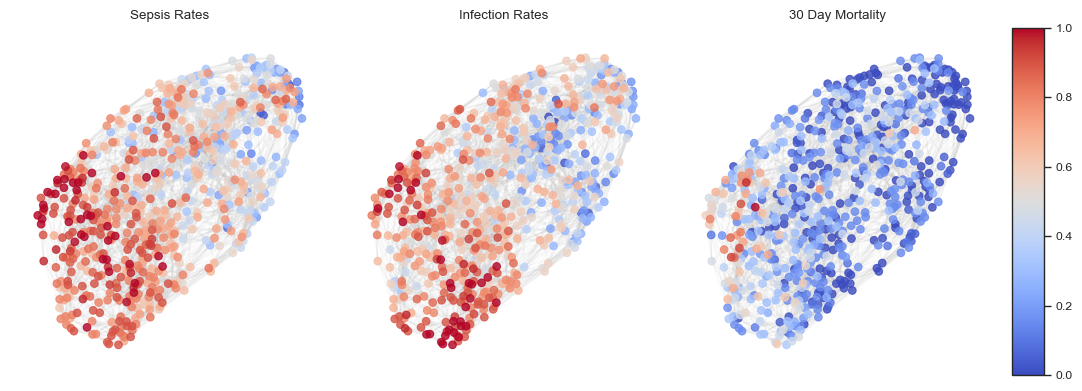

In [15]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    gridspec_kw={'width_ratios': [1, 1, 1, 0.1]}
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)



sm = plt.cm.ScalarMappable(cmap="coolwarm")
cbar = fig.colorbar(sm, cax=axs[-1], orientation="vertical")


fig.set_size_inches(((8.27 * 2) * .66 , 4))
plt.tight_layout()

fig.savefig(
    "sepsis_df_model_maps.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)

In [16]:
testing_data['Sepsis Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
sepsis_bootstrap_df = df_estimator.bootstrap_results_df.copy()
testing_data['Infection Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="verified_infection", bootstrap=True)
infection_bootstrap_df = df_estimator.bootstrap_results_df.copy()
testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
mortality_bootstrap_df = df_estimator.bootstrap_results_df.copy()

In [17]:
sepsis_bootstrap_df = sepsis_bootstrap_df.join(
    testing_data
)

sepsis_bootstrap_df.to_csv(
    "sepsis_bootstrap_hero.csv",
)

mortality_bootstrap_df = mortality_bootstrap_df.join(
    testing_data
)
mortality_bootstrap_df.to_csv(
    "mortality_bootstrap_hero.csv",
)

infection_bootstrap_df = infection_bootstrap_df.join(
    testing_data
)

infection_bootstrap_df.to_csv(
    "infection_bootstrap_hero.csv",
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: t-test independent samples, P_val:2.870e-13 t=-7.595e+00


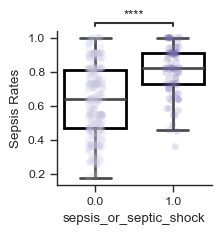

In [18]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=testing_data,
    y="Sepsis Rates",
    x="sepsis_or_septic_shock",
    hue="sepsis_or_septic_shock",
    ax=ax,
    palette="Purples",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=testing_data,
    y="Sepsis Rates",
    x="sepsis_or_septic_shock",
    hue="sepsis_or_septic_shock",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=testing_data, x="sepsis_or_septic_shock", y="Sepsis Rates")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 2)

fig.savefig(
    "sepsis_test.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: t-test independent samples, P_val:1.175e-12 t=-7.380e+00


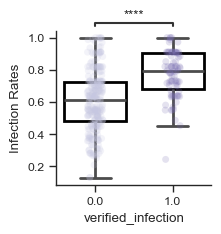

In [19]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=testing_data,
    y="Infection Rates",
    x="verified_infection",
    hue="verified_infection",
    ax=ax,
    palette="Purples",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=testing_data,
    y="Infection Rates",
    x="verified_infection",
    hue="verified_infection",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=testing_data, x="verified_infection", y="Infection Rates")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 2)

fig.savefig(
    "infection_test.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:4.308e-06 t=-4.670e+00


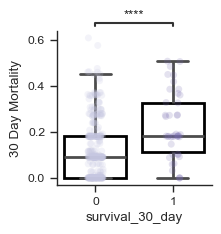

In [20]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=testing_data,
    y="30 Day Mortality",
    x="survival_30_day",
    hue="survival_30_day",
    ax=ax,
    palette="Purples",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=testing_data,
    y="30 Day Mortality",
    x="survival_30_day",
    hue="survival_30_day",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=testing_data, x="survival_30_day", y="30 Day Mortality")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 2)

fig.savefig(
    "mortality_test.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)